In [ ]:
import warnings
warnings.simplefilter(action="ignore", category=FutureWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import bioframe as bf

from ggner_3d.bbi_helpers import stackup_bw_dict
from ggner_3d import plotting
plotting.update_rcparams()


In [ ]:

# -----------------------------
# Paths
# -----------------------------
xpc_peaks = "/home/carlos/Clone/xpc_ctcf_peaks/XPC_all.narrowPeak"
ctcf_peaks = "/home/carlos/Clone/xpc_ctcf_peaks/CTCF_all.narrowPeak"
tss_bed = "/home/carlos/Clone/ggner-3d/tss.bed"

pol2_wt_dict = {
    "wt_nouv_pol2": ["/home/carlos/Clone/ggner-3d/GSM7162996_NCRNAPolIIChIP.primary.ucsc.bw"]
}
ctcf_wtnouv_dict = {
    "wt_nouv_ctcf": [
        "/home/carlos/oldies/ner_collab/ctcf/bigwigs_rpgc/WT_NoUV_REP1.mLb.clN.rpgc.bw",
        "/home/carlos/oldies/ner_collab/ctcf/bigwigs_rpgc/WT_NoUV_REP2.mLb.clN.rpgc.bw",
    ]
}
xpc_wtnouv_dict = {
    "wt_nouv_xpc": [
        "/home/carlos/oldies/ner_collab/xpc_chipseq/bigwigs_rpgc/XPC_WT_noUV_REP1.mLb.clN.rpgc.bw",
        "/home/carlos/oldies/ner_collab/xpc_chipseq/bigwigs_rpgc/XPC_WT_noUV_REP2.mLb.clN.rpgc.bw",
        "/home/carlos/oldies/ner_collab/xpc_chipseq/bigwigs_rpgc/XPC_WT_noUV_REP3.mLb.clN.rpgc.bw",
    ]
}

insul_csv = "/home/carlos/Clone/ggner-3d/data/insulation/insulation_WTnoUV_10000bp.csv"
insul_column = "log2_insulation_score_500000"
insul_resolution = 10_000

# -----------------------------
# Parameters
# -----------------------------
flank_small = 20_000
nbins_pol2 = 2000
nbins_promoter = 200

flank_large = 500_000
nbins_chip = 150

/home/carlos/Clone/ggner-3d/src/ggner_3d/bbi_helpers.py:18: RuntimeWarning: Mean of empty slice
  bw_dict_rep_avg = {k: np.nanmean(np.array(v), axis=0) for k, v in bw_dict_rep_avg.items()}
/home/carlos/Clone/ggner-3d/src/ggner_3d/bbi_helpers.py:18: RuntimeWarning: Mean of empty slice
  bw_dict_rep_avg = {k: np.nanmean(np.array(v), axis=0) for k, v in bw_dict_rep_avg.items()}
/home/carlos/Clone/ggner-3d/src/ggner_3d/bbi_helpers.py:18: RuntimeWarning: Mean of empty slice
  bw_dict_rep_avg = {k: np.nanmean(np.array(v), axis=0) for k, v in bw_dict_rep_avg.items()}
/home/carlos/Clone/ggner-3d/src/ggner_3d/bbi_helpers.py:18: RuntimeWarning: Mean of empty slice
  bw_dict_rep_avg = {k: np.nanmean(np.array(v), axis=0) for k, v in bw_dict_rep_avg.items()}
/home/carlos/Clone/ggner-3d/src/ggner_3d/bbi_helpers.py:18: RuntimeWarning: Mean of empty slice
  bw_dict_rep_avg = {k: np.nanmean(np.array(v), axis=0) for k, v in bw_dict_rep_avg.items()}
/home/carlos/Clone/ggner-3d/src/ggner_3d/bbi_helpers.py

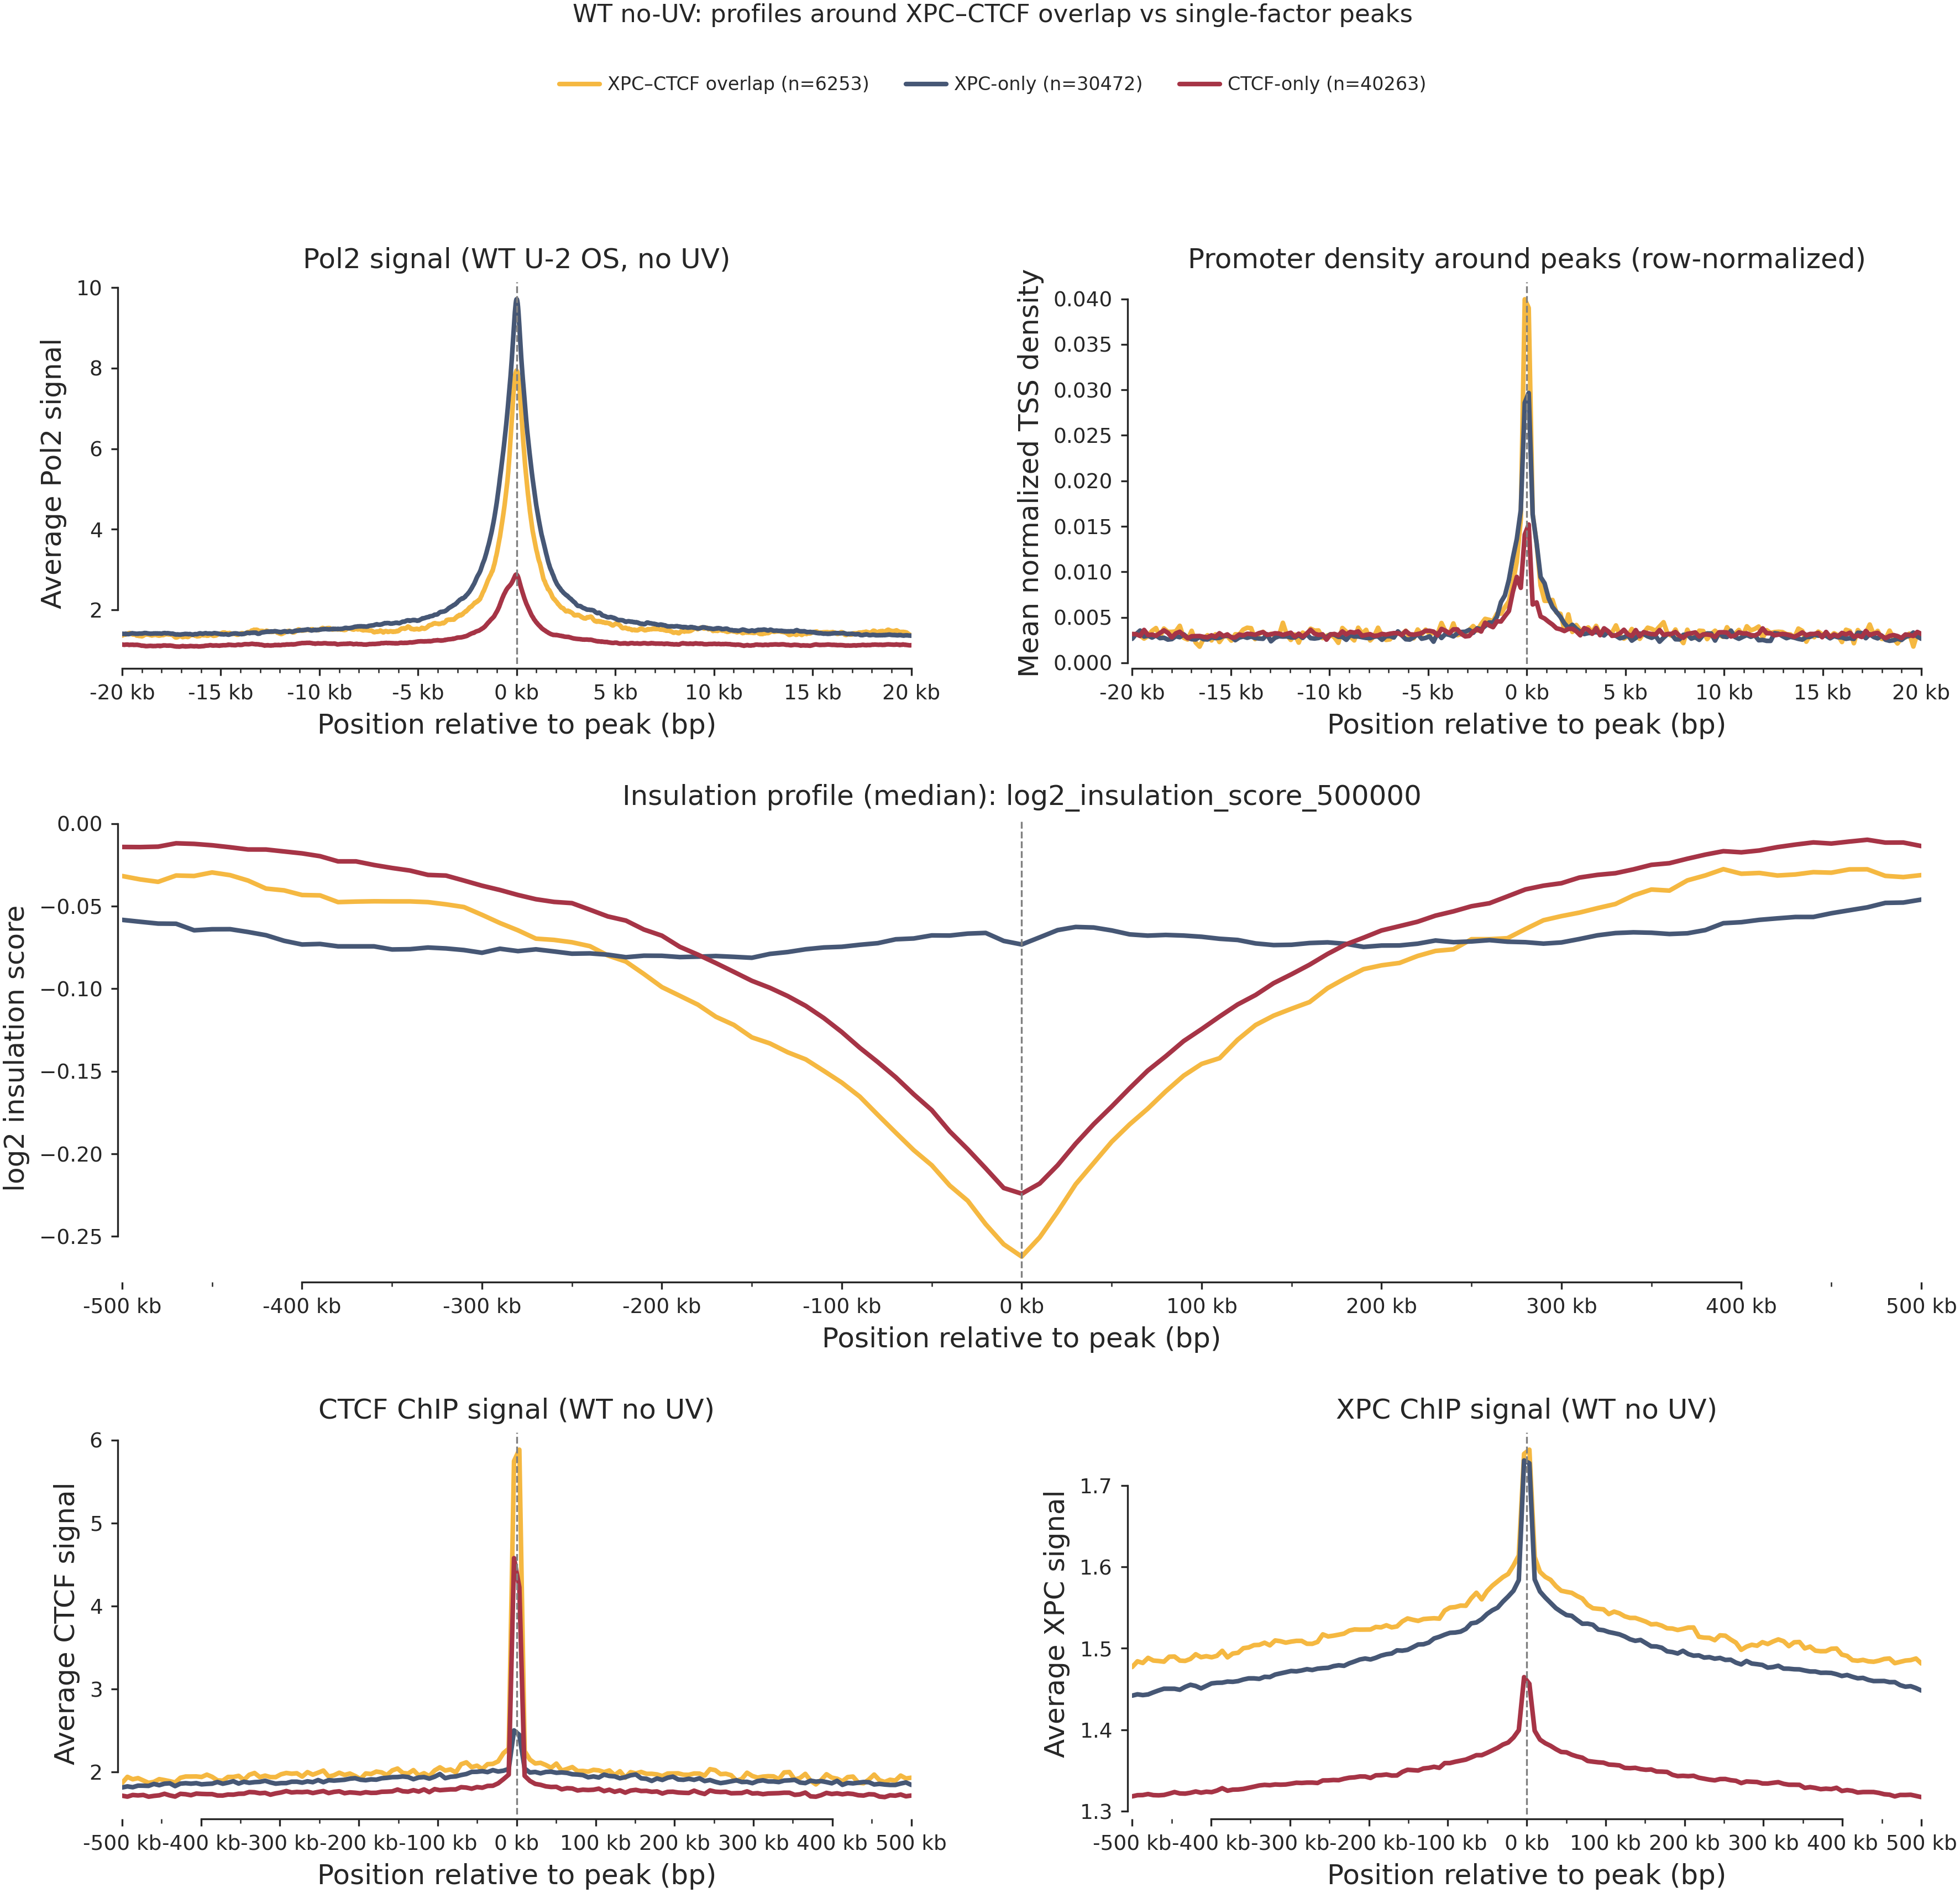

In [1]:


# -----------------------------
# Helpers
# -----------------------------
def filter_canonical_chromosomes(df, chrom_col="chrom"):
    canonical = [f"chr{i}" for i in range(1, 23)] + ["chrX", "chrY"]
    return df[df[chrom_col].isin(canonical)].copy()

def load_narrowpeak(path):
    df = pd.read_csv(path, sep="\t", header=None)
    df = df[[0, 1, 2, 9]].rename(columns={0: "chrom", 1: "start", 2: "end", 9: "peak"})
    df["start"] = df["start"].astype(int)
    df["end"] = df["end"].astype(int)
    df["peak"] = df["peak"].astype(int)
    df = filter_canonical_chromosomes(df, "chrom")
    return df

def add_summit(df, summit_col):
    out = df.copy()
    out[summit_col] = (out["start"] + out["peak"] - 1).astype(int)
    return out

def make_coords(df, center_col, flank):
    """
    DF for stackup_bw_dict: chrom, flank_start, flank_end
    Also includes start/end aliases for other functions.
    """
    out = df[["chrom", center_col]].copy()
    out["flank_start"] = (out[center_col] - flank).astype(int)
    out["flank_end"]   = (out[center_col] + flank).astype(int)
    out["start"] = out["flank_start"]
    out["end"]   = out["flank_end"]
    return out[["chrom", "flank_start", "flank_end", "start", "end"]]

def rowwise_normalize(mat, eps=0.0, keep_zeros=True):
    mat = np.asarray(mat)
    row_sums = mat.sum(axis=1)
    denom = row_sums[:, None].astype(np.float64, copy=False) + eps
    if keep_zeros:
        denom = np.where(row_sums[:, None] == 0, 1.0, denom)
        norm = mat / denom
    else:
        norm = mat / denom
        norm[row_sums == 0] = np.nan
    return norm, row_sums

def promoter_density_2d(tss, coordinate_df, flank=100_000, n_bins=100):
    tss_coord = np.where(tss["strand"].values == "+", tss["start"].values, tss["end"].values)
    tss_df = pd.DataFrame({"chrom": tss["chrom"].values, "tss": tss_coord})

    coord_mid = ((coordinate_df["start"].values + coordinate_df["end"].values) // 2)
    coords_df = pd.DataFrame({"chrom": coordinate_df["chrom"].values, "mid": coord_mid})

    density = np.zeros((len(coords_df), n_bins), dtype=np.int32)
    bin_size = (2 * flank) / n_bins

    for chrom in coords_df["chrom"].unique():
        coord_idx = np.where(coords_df["chrom"].values == chrom)[0]
        tss_idx = np.where(tss_df["chrom"].values == chrom)[0]
        if len(coord_idx) == 0 or len(tss_idx) == 0:
            continue

        coord_positions = coords_df["mid"].values[coord_idx]
        tss_positions = tss_df["tss"].values[tss_idx]

        dist = tss_positions[:, None] - coord_positions[None, :]
        mask = np.abs(dist) <= flank

        bin_index = ((dist + flank) / bin_size).astype(int)
        bin_index = np.clip(bin_index, 0, n_bins - 1)

        for tss_i in range(len(tss_positions)):
            valid = np.where(mask[tss_i])[0]
            if valid.size == 0:
                continue
            bins = bin_index[tss_i, valid]
            np.add.at(density, (coord_idx[valid], bins), 1)

    return density

def get_insulation_stack(insul_df, coord_df, insul_column, flank, resolution):
    insul_df = insul_df.copy()
    coord_df = coord_df.copy()

    insul_df["mid"] = ((insul_df["start"] + insul_df["end"]) // 2).astype(int)
    coord_df["mid"] = ((coord_df["start"] + coord_df["end"]) // 2).astype(int)

    bins_each_side = flank // resolution
    win_len = 2 * bins_each_side + 1

    out = []
    for chrom in coord_df["chrom"].unique():
        ins = insul_df[insul_df["chrom"] == chrom].reset_index(drop=True)
        coords = coord_df[coord_df["chrom"] == chrom].reset_index(drop=True)
        if ins.empty or coords.empty:
            continue

        mids = ins["mid"].values
        vals = ins[insul_column].values

        for mid in coords["mid"].values:
            idx = np.searchsorted(mids, mid)
            if idx <= 0:
                nearest = 0
            elif idx >= len(mids):
                nearest = len(mids) - 1
            else:
                nearest = idx if abs(mids[idx] - mid) < abs(mids[idx - 1] - mid) else idx - 1

            s = nearest - bins_each_side
            e = nearest + bins_each_side + 1
            if s < 0 or e > len(vals):
                continue

            seg = vals[s:e]
            if len(seg) == win_len:
                out.append(seg)

    return np.asarray(out)

def format_genomic_xaxis(ax, flank, major_bp, minor_bp):
    ax.set_xlim(-flank, flank)
    ax.axvline(0, linestyle="--", linewidth=0.8, color="0.5")
    ax.xaxis.set_major_locator(mticker.MultipleLocator(major_bp))
    ax.xaxis.set_minor_locator(mticker.MultipleLocator(minor_bp))
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, pos: f"{int(v/1000)} kb"))

def mean_profile(stack):
    return np.nanmean(stack, axis=0)

def median_profile(stack):
    return np.nanmedian(stack, axis=0)

def plot_three(ax, x, y_overlap, y_xpc, y_ctcf, group_colors, labels):
    ax.plot(x, y_overlap, color=group_colors["overlap"], lw=2, label=labels["overlap"])
    ax.plot(x, y_xpc,     color=group_colors["xpc_only"], lw=2, label=labels["xpc_only"])
    ax.plot(x, y_ctcf,    color=group_colors["ctcf_only"], lw=2, label=labels["ctcf_only"])
    plotting.despine(ax)

# -----------------------------
# Peak sets: overlap / XPC-only / CTCF-only
# -----------------------------
xpc = add_summit(load_narrowpeak(xpc_peaks), "xpc_summit")
ctcf = add_summit(load_narrowpeak(ctcf_peaks), "ctcf_summit")

ov = bf.overlap(
    xpc[["chrom", "start", "end", "peak"]],
    ctcf[["chrom", "start", "end", "peak"]],
).dropna(subset=["start_"]).copy()
ov = filter_canonical_chromosomes(ov, "chrom")
ov["xpc_summit"] = (ov["start"]  + ov["peak"]  - 1).astype(int)
ov["ctcf_summit"] = (ov["start_"] + ov["peak_"] - 1).astype(int)
ov["center_point"] = ((ov["xpc_summit"] + ov["ctcf_summit"]) // 2).astype(int)

xpc_only = bf.subtract(
    xpc[["chrom", "start", "end", "peak"]],
    ctcf[["chrom", "start", "end", "peak"]],
).copy()
xpc_only = filter_canonical_chromosomes(xpc_only, "chrom")
xpc_only["xpc_summit"] = (xpc_only["start"] + xpc_only["peak"] - 1).astype(int)

ctcf_only = bf.subtract(
    ctcf[["chrom", "start", "end", "peak"]],
    xpc[["chrom", "start", "end", "peak"]],
).copy()
ctcf_only = filter_canonical_chromosomes(ctcf_only, "chrom")
ctcf_only["ctcf_summit"] = (ctcf_only["start"] + ctcf_only["peak"] - 1).astype(int)

# Coords with flank_start/flank_end (stackup_bw_dict) AND start/end aliases
coords_small = {
    "overlap":   make_coords(ov, "center_point", flank_small),
    "xpc_only":  make_coords(xpc_only, "xpc_summit", flank_small),
    "ctcf_only": make_coords(ctcf_only, "ctcf_summit", flank_small),
}
coords_large = {
    "overlap":   make_coords(ov, "center_point", flank_large),
    "xpc_only":  make_coords(xpc_only, "xpc_summit", flank_large),
    "ctcf_only": make_coords(ctcf_only, "ctcf_summit", flank_large),
}

# -----------------------------
# Stackups: Pol2 / CTCF / XPC
# -----------------------------
pol2_stack = {
    k: stackup_bw_dict(pol2_wt_dict, coords_small[k][["chrom", "flank_start", "flank_end"]], nbins=nbins_pol2)["wt_nouv_pol2"]
    for k in coords_small
}
ctcf_stack = {
    k: stackup_bw_dict(ctcf_wtnouv_dict, coords_large[k][["chrom", "flank_start", "flank_end"]], nbins=nbins_chip)["wt_nouv_ctcf"]
    for k in coords_large
}
xpc_stack = {
    k: stackup_bw_dict(xpc_wtnouv_dict, coords_large[k][["chrom", "flank_start", "flank_end"]], nbins=nbins_chip)["wt_nouv_xpc"]
    for k in coords_large
}

# -----------------------------
# Load TSS and compute prom_prof  ✅ (THIS IS WHAT YOU'RE MISSING)
# -----------------------------
tss = pd.read_csv(tss_bed, sep="\t", header=None)
tss.columns = ["chrom", "start", "end", "gene", "score", "strand"]
tss["start"] = tss["start"].astype(int)
tss["end"] = tss["end"].astype(int)
tss = filter_canonical_chromosomes(tss, "chrom")

prom_mat = {
    k: promoter_density_2d(tss, coords_small[k][["chrom", "start", "end"]], flank=flank_small, n_bins=nbins_promoter)
    for k in coords_small
}

prom_prof = {}
for k, mat in prom_mat.items():
    norm, _ = rowwise_normalize(mat, keep_zeros=True)
    prom_prof[k] = np.nanmean(norm, axis=0)

# -----------------------------
# Load insulation and compute insulation profiles
# -----------------------------
insul = pd.read_csv(insul_csv)
insul = filter_canonical_chromosomes(insul, "chrom")

ins_stack = {
    k: get_insulation_stack(insul, coords_large[k][["chrom", "start", "end"]],
                            insul_column=insul_column, flank=flank_large, resolution=insul_resolution)
    for k in coords_large
}
ins_prof = {}
win_len = 2 * (flank_large // insul_resolution) + 1
for k, st in ins_stack.items():
    ins_prof[k] = median_profile(st) if st.size else np.full((win_len,), np.nan)

# -----------------------------
# Plot: single multi-panel figure
# -----------------------------
colors = plotting.COLORS
group_colors = {"overlap": colors[2], "xpc_only": colors[0], "ctcf_only": colors[1]}
labels = {
    "overlap":   f"XPC–CTCF overlap (n={len(coords_small['overlap'])})",
    "xpc_only":  f"XPC-only (n={len(coords_small['xpc_only'])})",
    "ctcf_only": f"CTCF-only (n={len(coords_small['ctcf_only'])})",
}

fig = plt.figure(figsize=(14, 12))
gs = fig.add_gridspec(3, 2, height_ratios=[1.0, 1.2, 1.0], hspace=0.38, wspace=0.28)

ax_pol2 = fig.add_subplot(gs[0, 0])
ax_prom = fig.add_subplot(gs[0, 1])
ax_ins  = fig.add_subplot(gs[1, :])
ax_ctcf = fig.add_subplot(gs[2, 0])
ax_xpc  = fig.add_subplot(gs[2, 1])

# Pol2
x_pol2 = np.linspace(-flank_small, flank_small, nbins_pol2)
plot_three(ax_pol2, x_pol2,
           mean_profile(pol2_stack["overlap"]),
           mean_profile(pol2_stack["xpc_only"]),
           mean_profile(pol2_stack["ctcf_only"]),
           group_colors, labels)
ax_pol2.set_title("Pol2 signal (WT U-2 OS, no UV)")
ax_pol2.set_xlabel("Position relative to peak (bp)")
ax_pol2.set_ylabel("Average Pol2 signal")
format_genomic_xaxis(ax_pol2, flank_small, major_bp=5_000, minor_bp=1_000)

# Promoter density
x_prom = np.linspace(-flank_small, flank_small, nbins_promoter)
plot_three(ax_prom, x_prom,
           prom_prof["overlap"],
           prom_prof["xpc_only"],
           prom_prof["ctcf_only"],
           group_colors, labels)
ax_prom.set_title("Promoter density around peaks (row-normalized)")
ax_prom.set_xlabel("Position relative to peak (bp)")
ax_prom.set_ylabel("Mean normalized TSS density")
format_genomic_xaxis(ax_prom, flank_small, major_bp=5_000, minor_bp=1_000)

# Insulation
x_ins = np.linspace(-flank_large, flank_large, win_len)
plot_three(ax_ins, x_ins,
           ins_prof["overlap"],
           ins_prof["xpc_only"],
           ins_prof["ctcf_only"],
           group_colors, labels)
ax_ins.set_title(f"Insulation profile (median): {insul_column}")
ax_ins.set_xlabel("Position relative to peak (bp)")
ax_ins.set_ylabel("log2 insulation score")
format_genomic_xaxis(ax_ins, flank_large, major_bp=100_000, minor_bp=50_000)

# CTCF ChIP
x_chip = np.linspace(-flank_large, flank_large, nbins_chip)
plot_three(ax_ctcf, x_chip,
           mean_profile(ctcf_stack["overlap"]),
           mean_profile(ctcf_stack["xpc_only"]),
           mean_profile(ctcf_stack["ctcf_only"]),
           group_colors, labels)
ax_ctcf.set_title("CTCF ChIP signal (WT no UV)")
ax_ctcf.set_xlabel("Position relative to peak (bp)")
ax_ctcf.set_ylabel("Average CTCF signal")
format_genomic_xaxis(ax_ctcf, flank_large, major_bp=100_000, minor_bp=50_000)

# XPC ChIP
plot_three(ax_xpc, x_chip,
           mean_profile(xpc_stack["overlap"]),
           mean_profile(xpc_stack["xpc_only"]),
           mean_profile(xpc_stack["ctcf_only"]),
           group_colors, labels)
ax_xpc.set_title("XPC ChIP signal (WT no UV)")
ax_xpc.set_xlabel("Position relative to peak (bp)")
ax_xpc.set_ylabel("Average XPC signal")
format_genomic_xaxis(ax_xpc, flank_large, major_bp=100_000, minor_bp=50_000)

# One shared legend
handles, leg_labels = ax_pol2.get_legend_handles_labels()
fig.legend(handles, leg_labels, loc="upper center", ncol=3, frameon=False, bbox_to_anchor=(0.5, 0.99))

fig.suptitle("WT no-UV: profiles around XPC–CTCF overlap vs single-factor peaks", y=1.02)
plt.tight_layout()
plt.show()

# Optional save:
# fig.savefig("xpc_ctcf_multiplot_panel.pdf", bbox_inches="tight")